In [1]:
import cv2
import os

# -------- VIDEO LIST --------
videos = ["road.mp4", "road2.mp4"]   # add your video names here

num_frames = 30

for video_path in videos:

    # Video name without extension
    video_name = os.path.splitext(video_path)[0]

    # Output folders for each video
    output_folder = f"{video_name}_extracted_frames"
    gray_folder = f"{video_name}_grayscale_frames"

    # Create folders
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(gray_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error opening video {video_path}")
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Select equally spaced frames
    frame_indices = [int(i * total_frames / num_frames) for i in range(num_frames)]

    for idx, frame_no in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ret, frame = cap.read()

        if not ret:
            print(f"Failed to read frame {frame_no} from {video_path}")
            continue

        # Save original frame
        cv2.imwrite(f"{output_folder}/frame_{idx+1}.jpg", frame)

        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Save grayscale frame
        cv2.imwrite(f"{gray_folder}/gray_{idx+1}.jpg", gray)

        print(f"{video_name}: Saved frame_{idx+1}.jpg and gray_{idx+1}.jpg")

    cap.release()

print("Extraction completed for all videos.")

road: Saved frame_1.jpg and gray_1.jpg
road: Saved frame_2.jpg and gray_2.jpg
road: Saved frame_3.jpg and gray_3.jpg
road: Saved frame_4.jpg and gray_4.jpg
road: Saved frame_5.jpg and gray_5.jpg
road: Saved frame_6.jpg and gray_6.jpg
road: Saved frame_7.jpg and gray_7.jpg
road: Saved frame_8.jpg and gray_8.jpg
road: Saved frame_9.jpg and gray_9.jpg
road: Saved frame_10.jpg and gray_10.jpg
road: Saved frame_11.jpg and gray_11.jpg
road: Saved frame_12.jpg and gray_12.jpg
road: Saved frame_13.jpg and gray_13.jpg
road: Saved frame_14.jpg and gray_14.jpg
road: Saved frame_15.jpg and gray_15.jpg
road: Saved frame_16.jpg and gray_16.jpg
road: Saved frame_17.jpg and gray_17.jpg
road: Saved frame_18.jpg and gray_18.jpg
road: Saved frame_19.jpg and gray_19.jpg
road: Saved frame_20.jpg and gray_20.jpg
road: Saved frame_21.jpg and gray_21.jpg
road: Saved frame_22.jpg and gray_22.jpg
road: Saved frame_23.jpg and gray_23.jpg
road: Saved frame_24.jpg and gray_24.jpg
road: Saved frame_25.jpg and gray_


Processing road...


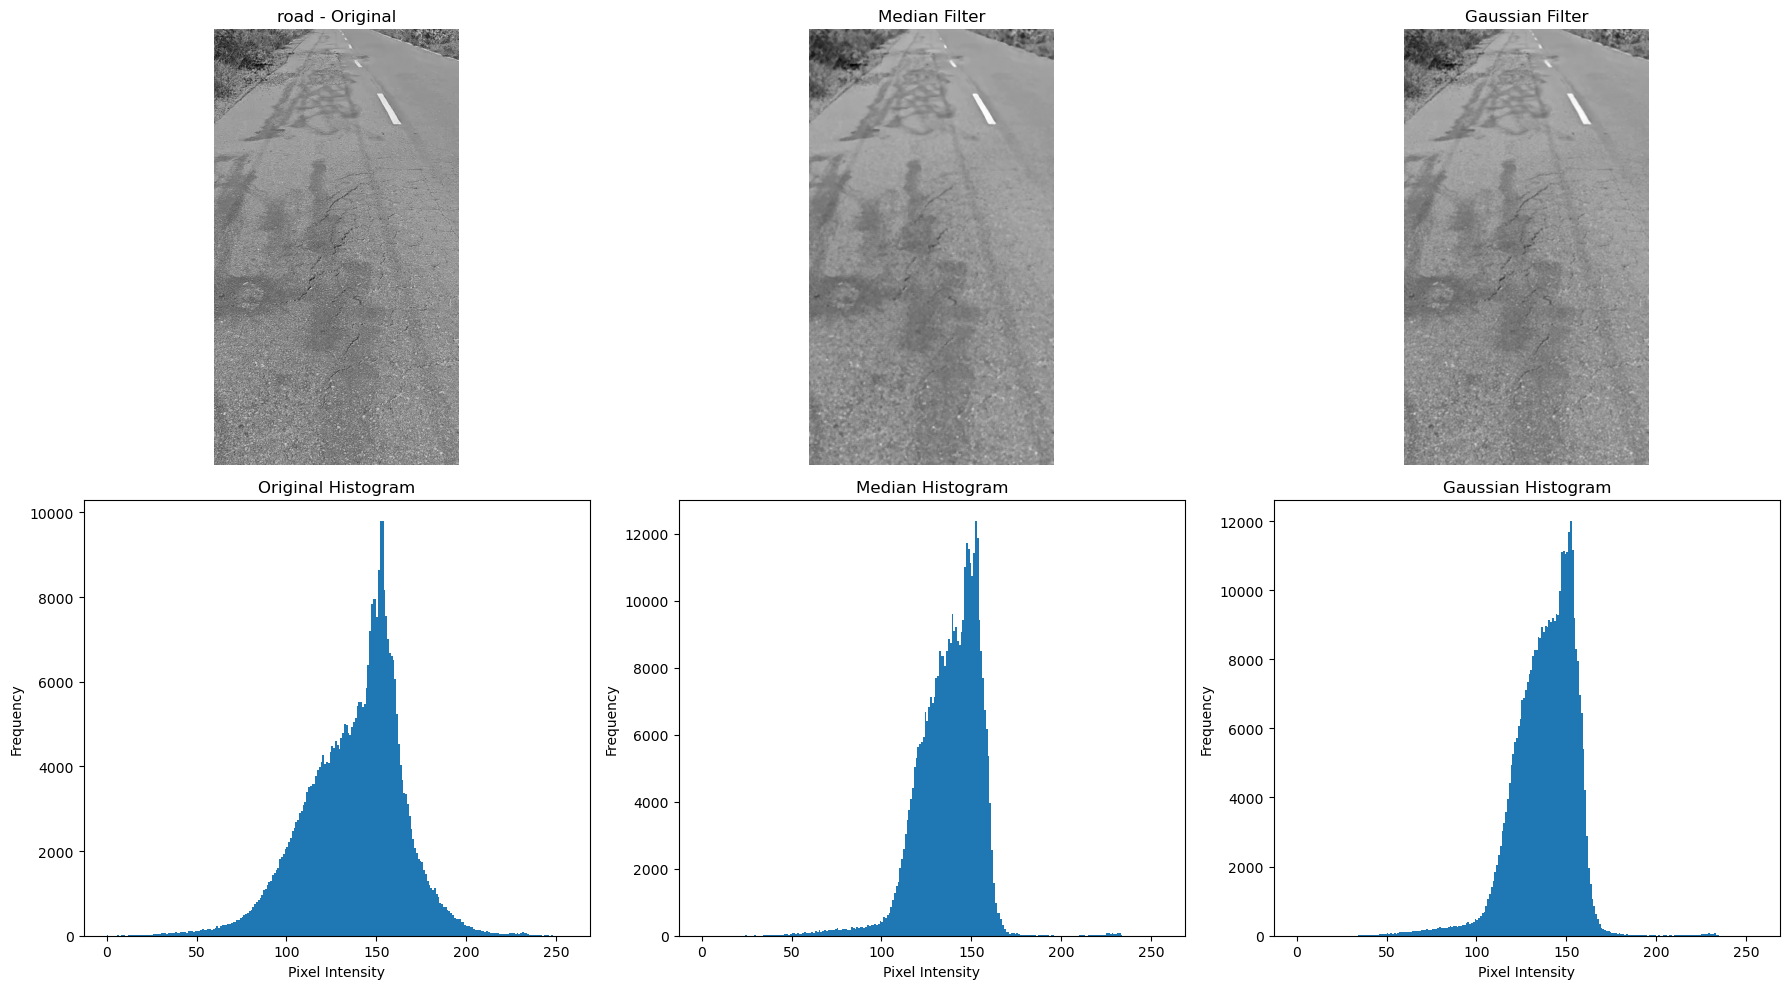

road: Frame 1 processed and saved
road: Frame 2 processed and saved
road: Frame 3 processed and saved
road: Frame 4 processed and saved
road: Frame 5 processed and saved
road: Frame 6 processed and saved
road: Frame 7 processed and saved
road: Frame 8 processed and saved
road: Frame 9 processed and saved
road: Frame 10 processed and saved
road: Frame 11 processed and saved
road: Frame 12 processed and saved
road: Frame 13 processed and saved
road: Frame 14 processed and saved
road: Frame 15 processed and saved
road: Frame 16 processed and saved
road: Frame 17 processed and saved
road: Frame 18 processed and saved
road: Frame 19 processed and saved
road: Frame 20 processed and saved
road: Frame 21 processed and saved
road: Frame 22 processed and saved
road: Frame 23 processed and saved
road: Frame 24 processed and saved
road: Frame 25 processed and saved
road: Frame 26 processed and saved
road: Frame 27 processed and saved
road: Frame 28 processed and saved
road: Frame 29 processed and 

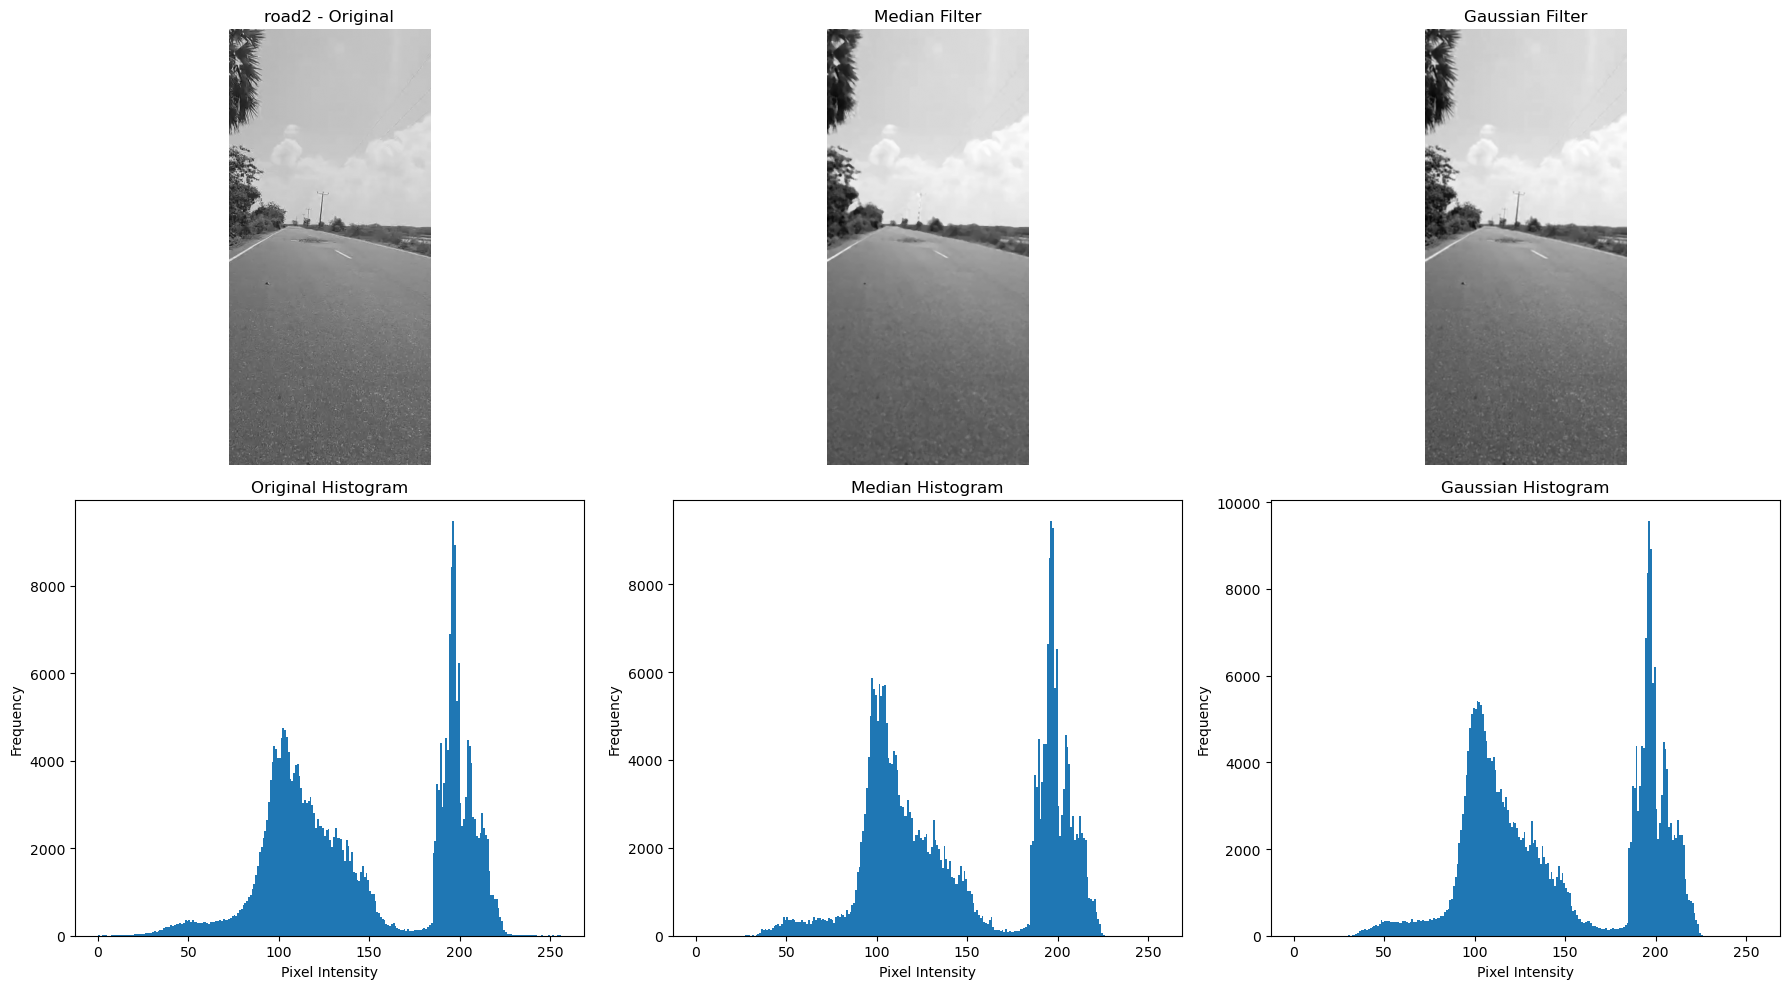

road2: Frame 1 processed and saved
road2: Frame 2 processed and saved
road2: Frame 3 processed and saved
road2: Frame 4 processed and saved
road2: Frame 5 processed and saved
road2: Frame 6 processed and saved
road2: Frame 7 processed and saved
road2: Frame 8 processed and saved
road2: Frame 9 processed and saved
road2: Frame 10 processed and saved
road2: Frame 11 processed and saved
road2: Frame 12 processed and saved
road2: Frame 13 processed and saved
road2: Frame 14 processed and saved
road2: Frame 15 processed and saved
road2: Frame 16 processed and saved
road2: Frame 17 processed and saved
road2: Frame 18 processed and saved
road2: Frame 19 processed and saved
road2: Frame 20 processed and saved
road2: Frame 21 processed and saved
road2: Frame 22 processed and saved
road2: Frame 23 processed and saved
road2: Frame 24 processed and saved
road2: Frame 25 processed and saved
road2: Frame 26 processed and saved
road2: Frame 27 processed and saved
road2: Frame 28 processed and saved
r

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- SETTINGS --------
num_frames = 30
display_frame = 1   
videos = ["road", "road2"]   

for video in videos:

    # -------- INPUT FOLDER --------
    frames_folder = f"{video}_grayscale_frames"

    # -------- OUTPUT FOLDERS --------
    median_folder = f"{video}_member1_median"
    gaussian_folder = f"{video}_member1_gaussian"
    comparison_folder = f"{video}_member1_comparisons"

    os.makedirs(median_folder, exist_ok=True)
    os.makedirs(gaussian_folder, exist_ok=True)
    os.makedirs(comparison_folder, exist_ok=True)

    print(f"\nProcessing {video}...")

    shown = False   

    for frame_number in range(1, num_frames + 1):

        # Read grayscale frame
        path = f"{frames_folder}/gray_{frame_number}.jpg"
        gray = cv2.imread(path, 0)

        if gray is None:
            print(f"Frame {frame_number} not found in {frames_folder}")
            continue

        # -------- APPLY FILTERS --------
        median_img = cv2.medianBlur(gray, 5)
        gaussian_img = cv2.GaussianBlur(gray, (5, 5), 0)

        # -------- SAVE FILTERED IMAGES --------
        cv2.imwrite(f"{median_folder}/frame_{frame_number}.jpg", median_img)
        cv2.imwrite(f"{gaussian_folder}/frame_{frame_number}.jpg", gaussian_img)

        # -------- CREATE AND SAVE COMPARISON FIGURE --------
        plt.figure(figsize=(18, 10))

        # Original Image
        plt.subplot(2, 3, 1)
        plt.imshow(gray, cmap='gray')
        plt.title(f"{video} - Original")
        plt.axis('off')

        # Median Filtered Image
        plt.subplot(2, 3, 2)
        plt.imshow(median_img, cmap='gray')
        plt.title("Median Filter")
        plt.axis('off')

        # Gaussian Filtered Image
        plt.subplot(2, 3, 3)
        plt.imshow(gaussian_img, cmap='gray')
        plt.title("Gaussian Filter")
        plt.axis('off')

        # Original Histogram
        plt.subplot(2, 3, 4)
        plt.hist(gray.ravel(), bins=256, range=[0, 256])
        plt.title("Original Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        # Median Histogram
        plt.subplot(2, 3, 5)
        plt.hist(median_img.ravel(), bins=256, range=[0, 256])
        plt.title("Median Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        # Gaussian Histogram
        plt.subplot(2, 3, 6)
        plt.hist(gaussian_img.ravel(), bins=256, range=[0, 256])
        plt.title("Gaussian Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.savefig(f"{comparison_folder}/comparison_frame_{frame_number}.png")

        # -------- SHOW ONLY ONE FRAME IN NOTEBOOK --------
        if frame_number == display_frame and not shown:
            plt.show()
            shown = True
        else:
            plt.close()

        print(f"{video}: Frame {frame_number} processed and saved")

print("\nAll frames processed successfully.")


Processing road...


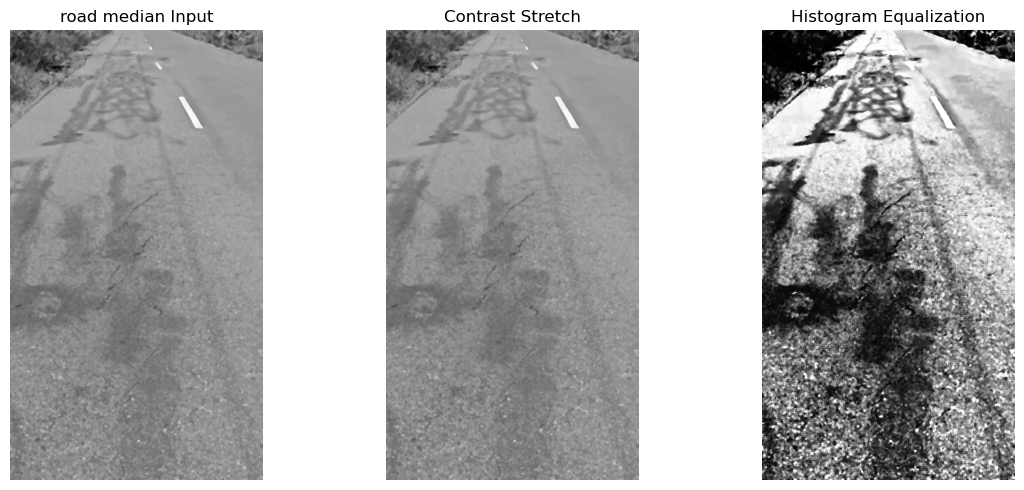

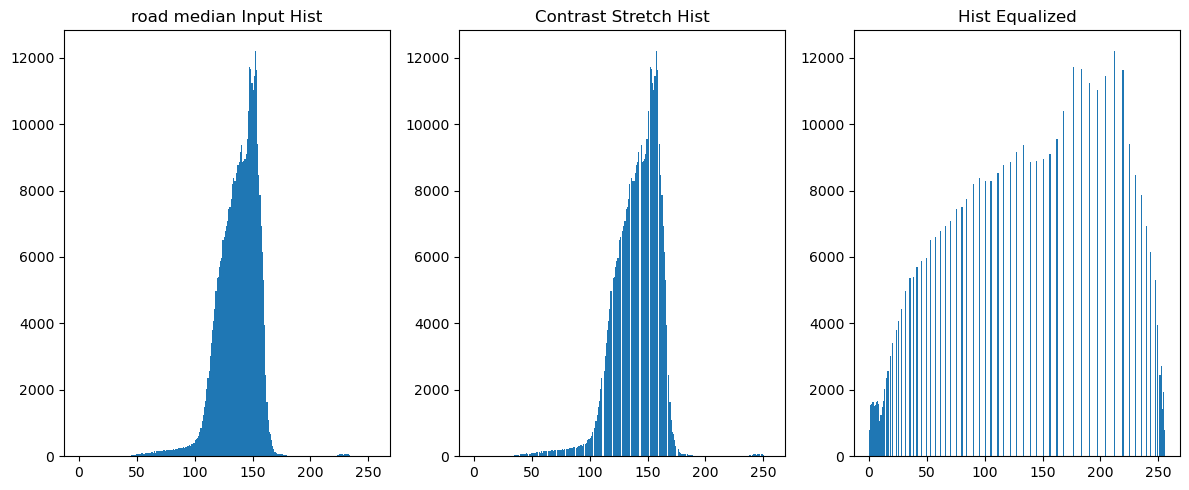

road: Processed median frame 1
road: Processed gaussian frame 1
road: Processed median frame 2
road: Processed gaussian frame 2
road: Processed median frame 3
road: Processed gaussian frame 3
road: Processed median frame 4
road: Processed gaussian frame 4
road: Processed median frame 5
road: Processed gaussian frame 5
road: Processed median frame 6
road: Processed gaussian frame 6
road: Processed median frame 7
road: Processed gaussian frame 7
road: Processed median frame 8
road: Processed gaussian frame 8
road: Processed median frame 9
road: Processed gaussian frame 9
road: Processed median frame 10
road: Processed gaussian frame 10
road: Processed median frame 11
road: Processed gaussian frame 11
road: Processed median frame 12
road: Processed gaussian frame 12
road: Processed median frame 13
road: Processed gaussian frame 13
road: Processed median frame 14
road: Processed gaussian frame 14
road: Processed median frame 15
road: Processed gaussian frame 15
road: Processed median frame

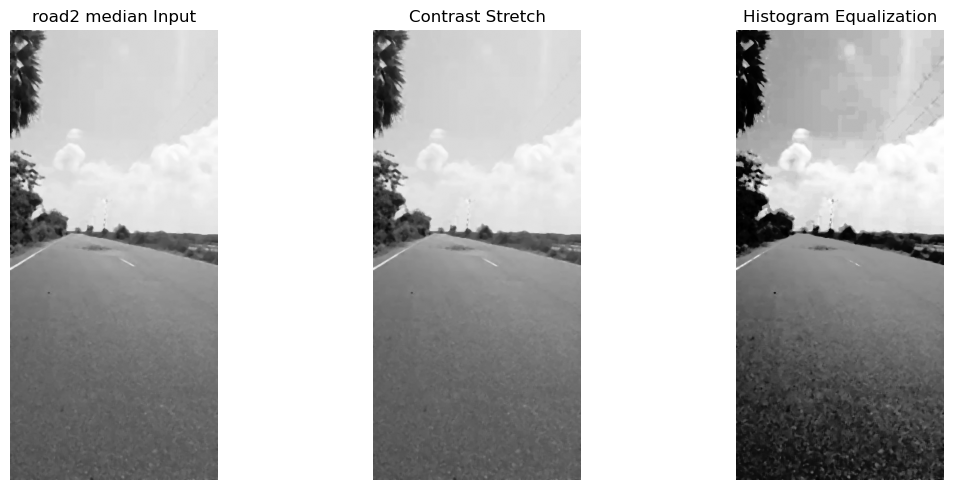

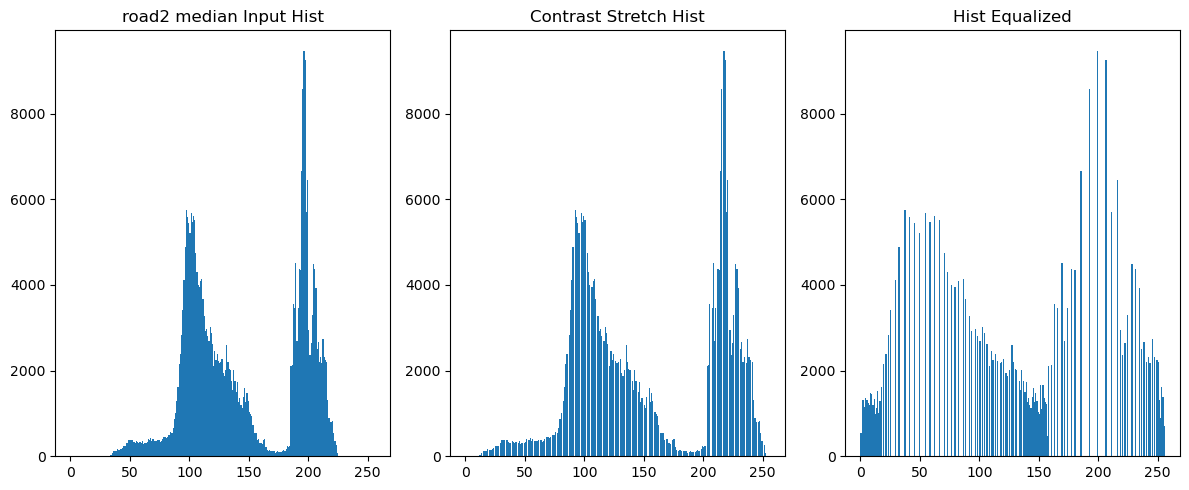

road2: Processed median frame 1
road2: Processed gaussian frame 1
road2: Processed median frame 2
road2: Processed gaussian frame 2
road2: Processed median frame 3
road2: Processed gaussian frame 3
road2: Processed median frame 4
road2: Processed gaussian frame 4
road2: Processed median frame 5
road2: Processed gaussian frame 5
road2: Processed median frame 6
road2: Processed gaussian frame 6
road2: Processed median frame 7
road2: Processed gaussian frame 7
road2: Processed median frame 8
road2: Processed gaussian frame 8
road2: Processed median frame 9
road2: Processed gaussian frame 9
road2: Processed median frame 10
road2: Processed gaussian frame 10
road2: Processed median frame 11
road2: Processed gaussian frame 11
road2: Processed median frame 12
road2: Processed gaussian frame 12
road2: Processed median frame 13
road2: Processed gaussian frame 13
road2: Processed median frame 14
road2: Processed gaussian frame 14
road2: Processed median frame 15
road2: Processed gaussian frame 1

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

num_frames = 30
display_frame = 1   # to show one example frame in notebook
videos = ["road", "road2"]   # video names

def contrast_stretching(img):
    if img.max() == img.min():
        return img
    return ((img - img.min()) / (img.max() - img.min()) * 255).astype('uint8')

for video in videos:

    print(f"\nProcessing {video}...")

    # -------- INPUT FOLDERS --------
    input_folders = {
        "median": f"{video}_member1_median",
        "gaussian": f"{video}_member1_gaussian"
    }

    # -------- OUTPUT FOLDERS --------
    output_folders = {
        "median_contrast": f"{video}_member2_median_contrast",
        "median_hist_eq": f"{video}_member2_median_hist_eq",
        "gaussian_contrast": f"{video}_member2_gaussian_contrast",
        "gaussian_hist_eq": f"{video}_member2_gaussian_hist_eq",
        "comparisons": f"{video}_member2_comparisons",
        "histograms": f"{video}_member2_histograms"
    }

    # Create folders
    for folder in output_folders.values():
        os.makedirs(folder, exist_ok=True)

    shown_image = False
    shown_hist = False

    for idx in range(1, num_frames + 1):

        for filter_type in input_folders:

            input_path = f"{input_folders[filter_type]}/frame_{idx}.jpg"
            img = cv2.imread(input_path, 0)

            if img is None:
                print(f"{video} {filter_type} frame {idx} not found")
                continue

            # -------- ENHANCEMENT --------
            contrast_img = contrast_stretching(img)
            hist_eq_img = cv2.equalizeHist(img)

            # -------- SAVE ENHANCED IMAGES --------
            cv2.imwrite(
                f"{output_folders[f'{filter_type}_contrast']}/frame_{idx}.jpg",
                contrast_img
            )

            cv2.imwrite(
                f"{output_folders[f'{filter_type}_hist_eq']}/frame_{idx}.jpg",
                hist_eq_img
            )

            # -------- IMAGE COMPARISON --------
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{video} {filter_type} Input")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(contrast_img, cmap='gray')
            plt.title("Contrast Stretch")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(hist_eq_img, cmap='gray')
            plt.title("Histogram Equalization")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(
                f"{output_folders['comparisons']}/{filter_type}_comparison_{idx}.jpg"
            )

            # Show only one selected frame in notebook for each video
            if idx == display_frame and not shown_image:
                plt.show()
                shown_image = True
            else:
                plt.close()

            # -------- HISTOGRAM COMPARISON --------
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 3, 1)
            plt.hist(img.ravel(), bins=256, range=[0, 256])
            plt.title(f"{video} {filter_type} Input Hist")

            plt.subplot(1, 3, 2)
            plt.hist(contrast_img.ravel(), bins=256, range=[0, 256])
            plt.title("Contrast Stretch Hist")

            plt.subplot(1, 3, 3)
            plt.hist(hist_eq_img.ravel(), bins=256, range=[0, 256])
            plt.title("Hist Equalized")

            plt.tight_layout()
            plt.savefig(
                f"{output_folders['histograms']}/{filter_type}_hist_{idx}.png"
            )

            # Show only one histogram in notebook for each video
            if idx == display_frame and not shown_hist:
                plt.show()
                shown_hist = True
            else:
                plt.close()

            print(f"{video}: Processed {filter_type} frame {idx}")

print("\nMember 2 processing complete.")


Processing road...


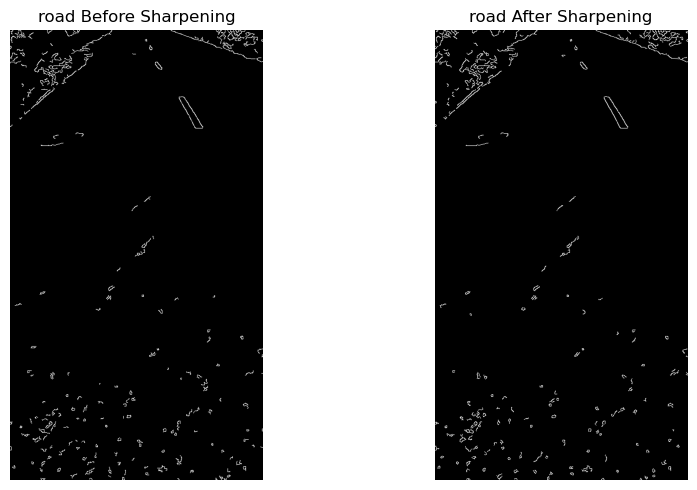

road: Processed median_contrast frame 1
road: Processed median_hist_eq frame 1


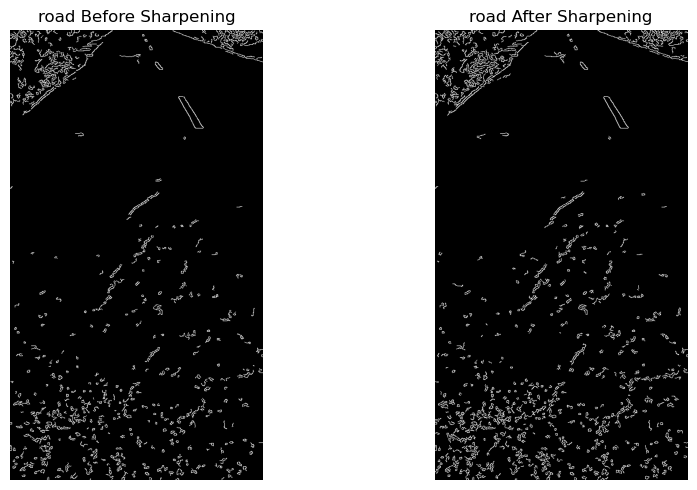

road: Processed gaussian_contrast frame 1
road: Processed gaussian_hist_eq frame 1
road: Processed median_contrast frame 2
road: Processed median_hist_eq frame 2
road: Processed gaussian_contrast frame 2
road: Processed gaussian_hist_eq frame 2
road: Processed median_contrast frame 3
road: Processed median_hist_eq frame 3
road: Processed gaussian_contrast frame 3
road: Processed gaussian_hist_eq frame 3
road: Processed median_contrast frame 4
road: Processed median_hist_eq frame 4
road: Processed gaussian_contrast frame 4
road: Processed gaussian_hist_eq frame 4
road: Processed median_contrast frame 5
road: Processed median_hist_eq frame 5
road: Processed gaussian_contrast frame 5
road: Processed gaussian_hist_eq frame 5
road: Processed median_contrast frame 6
road: Processed median_hist_eq frame 6
road: Processed gaussian_contrast frame 6
road: Processed gaussian_hist_eq frame 6
road: Processed median_contrast frame 7
road: Processed median_hist_eq frame 7
road: Processed gaussian_con

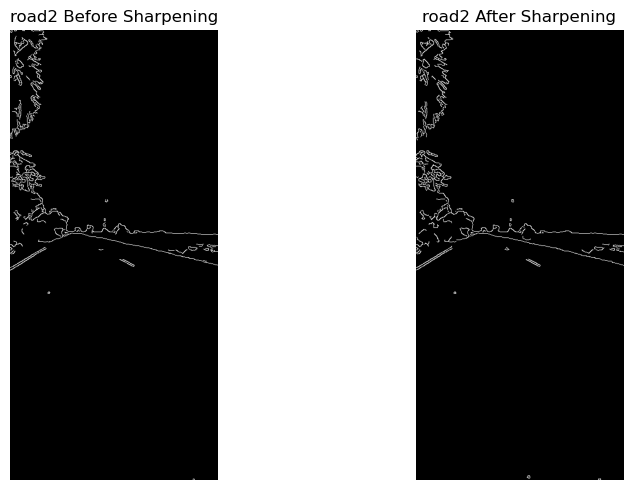

road2: Processed median_contrast frame 1
road2: Processed median_hist_eq frame 1


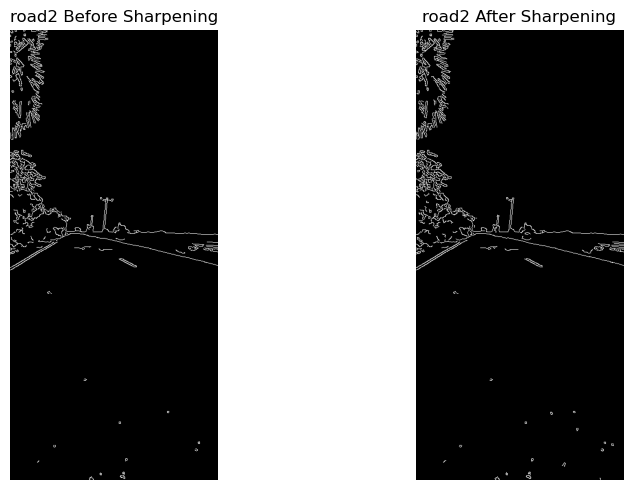

road2: Processed gaussian_contrast frame 1
road2: Processed gaussian_hist_eq frame 1
road2: Processed median_contrast frame 2
road2: Processed median_hist_eq frame 2
road2: Processed gaussian_contrast frame 2
road2: Processed gaussian_hist_eq frame 2
road2: Processed median_contrast frame 3
road2: Processed median_hist_eq frame 3
road2: Processed gaussian_contrast frame 3
road2: Processed gaussian_hist_eq frame 3
road2: Processed median_contrast frame 4
road2: Processed median_hist_eq frame 4
road2: Processed gaussian_contrast frame 4
road2: Processed gaussian_hist_eq frame 4
road2: Processed median_contrast frame 5
road2: Processed median_hist_eq frame 5
road2: Processed gaussian_contrast frame 5
road2: Processed gaussian_hist_eq frame 5
road2: Processed median_contrast frame 6
road2: Processed median_hist_eq frame 6
road2: Processed gaussian_contrast frame 6
road2: Processed gaussian_hist_eq frame 6
road2: Processed median_contrast frame 7
road2: Processed median_hist_eq frame 7
road

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

num_frames = 30
display_frame = 1   # show only one frame in notebook
videos = ["road", "road2"]   # video names

def sharpen_image(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

def sharpness_metric(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

def edge_image(img):
    return cv2.Canny(img, 100, 200)

for video in videos:

    print(f"\nProcessing {video}...")

    # -------- INPUT FOLDERS FROM MEMBER 2 --------
    input_folders = {
        "median_contrast": f"{video}_member2_median_contrast",
        "median_hist_eq": f"{video}_member2_median_hist_eq",
        "gaussian_contrast": f"{video}_member2_gaussian_contrast",
        "gaussian_hist_eq": f"{video}_member2_gaussian_hist_eq"
    }

    # -------- OUTPUT FOLDERS --------
    output_folders = {
        "sharpened": f"{video}_member3_sharpened",
        "edges": f"{video}_member3_edges",
        "median_comparisons": f"{video}_member3_median_edge_comparisons",
        "gaussian_comparisons": f"{video}_member3_gaussian_edge_comparisons"
    }

    # Create folders
    for folder in output_folders.values():
        os.makedirs(folder, exist_ok=True)

    metrics = []
    shown_median = False
    shown_gaussian = False

    for idx in range(1, num_frames + 1):

        for method in input_folders:

            input_path = f"{input_folders[method]}/frame_{idx}.jpg"
            img = cv2.imread(input_path, 0)

            if img is None:
                print(f"{video} {method} frame {idx} not found")
                continue

            # Optional smoothing
            smoothed = cv2.GaussianBlur(img, (5, 5), 0)

            # Sharpen
            sharpened = sharpen_image(smoothed)

            # Save sharpened image
            cv2.imwrite(
                f"{output_folders['sharpened']}/{method}_frame_{idx}.jpg",
                sharpened
            )

            # Edge detection
            edges_input = edge_image(img)
            edges_sharp = edge_image(sharpened)

            cv2.imwrite(
                f"{output_folders['edges']}/{method}_edges_{idx}.jpg",
                edges_sharp
            )

            # Select comparison folder
            if "median" in method:
                comparison_folder = output_folders["median_comparisons"]
            else:
                comparison_folder = output_folders["gaussian_comparisons"]

            # -------- EDGE COMPARISON --------
            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(edges_input, cmap='gray')
            plt.title(f"{video} Before Sharpening")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(edges_sharp, cmap='gray')
            plt.title(f"{video} After Sharpening")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(f"{comparison_folder}/{method}_compare_{idx}.jpg")

            # Show only one median and one gaussian example for each video
            if idx == display_frame:
                if "median" in method and not shown_median:
                    plt.show()
                    shown_median = True
                elif "gaussian" in method and not shown_gaussian:
                    plt.show()
                    shown_gaussian = True
                else:
                    plt.close()
            else:
                plt.close()

            # Store metrics
            metrics.append({
                "Frame": idx,
                "Method": method,
                "Sharpness_Before": sharpness_metric(img),
                "Sharpness_After": sharpness_metric(sharpened)
            })

            print(f"{video}: Processed {method} frame {idx}")

    # Save metrics CSV for each video
    csv_name = f"{video}_member3_metrics.csv"
    with open(csv_name, "w") as f:
        f.write("Frame,Method,Sharpness_Before,Sharpness_After\n")
        for m in metrics:
            f.write(f"{m['Frame']},{m['Method']},{m['Sharpness_Before']},{m['Sharpness_After']}\n")

    print(f"{video} processing complete. Metrics saved in {csv_name}")

print("\nMember 3 processing complete for all videos.")

In [7]:
import cv2
import numpy as np
import os

num_frames = 30
videos = ["road", "road2"]   # video names

def sharpness(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

def contrast(img):
    return img.std()

for video in videos:

    print(f"\nProcessing {video}...")

    # -------- FOLDERS --------

    # Original grayscale folder
    original_folder = f"{video}_grayscale_frames"

    # Member 1 folders
    member1_folders = {
        "median": f"{video}_member1_median",
        "gaussian": f"{video}_member1_gaussian"
    }

    # Member 2 folders
    member2_folders = {
        "median_contrast": f"{video}_member2_median_contrast",
        "median_hist_eq": f"{video}_member2_median_hist_eq",
        "gaussian_contrast": f"{video}_member2_gaussian_contrast",
        "gaussian_hist_eq": f"{video}_member2_gaussian_hist_eq"
    }

    # Member 3 folder
    member3_folder = f"{video}_member3_sharpened"

    csv_file = f"{video}_final_results_table.csv"

    with open(csv_file, "w") as f:

        f.write("Frame,Method,Sharpness,Contrast\n")

        for i in range(1, num_frames + 1):

            # -------- ORIGINAL --------
            original_path = f"{original_folder}/gray_{i}.jpg"
            original = cv2.imread(original_path, 0)

            if original is not None:
                f.write(f"{i},original,{sharpness(original)},{contrast(original)}\n")

            # -------- MEMBER 1 --------
            for method in member1_folders:
                path = f"{member1_folders[method]}/frame_{i}.jpg"
                img = cv2.imread(path, 0)

                if img is not None:
                    f.write(f"{i},{method},{sharpness(img)},{contrast(img)}\n")

            # -------- MEMBER 2 --------
            for method in member2_folders:
                path = f"{member2_folders[method]}/frame_{i}.jpg"
                img = cv2.imread(path, 0)

                if img is not None:
                    f.write(f"{i},{method},{sharpness(img)},{contrast(img)}\n")

            # -------- MEMBER 3 --------
            for method in member2_folders:
                sharpened_path = f"{member3_folder}/{method}_frame_{i}.jpg"
                img = cv2.imread(sharpened_path, 0)

                if img is not None:
                    f.write(f"{i},{method}_sharpened,{sharpness(img)},{contrast(img)}\n")

            print(f"{video}: Processed frame {i}")

    print(f"{video}: Final results table created successfully as {csv_file}")

print("\nAll final results tables created successfully!")


Processing road...
road: Processed frame 1
road: Processed frame 2
road: Processed frame 3
road: Processed frame 4
road: Processed frame 5
road: Processed frame 6
road: Processed frame 7
road: Processed frame 8
road: Processed frame 9
road: Processed frame 10
road: Processed frame 11
road: Processed frame 12
road: Processed frame 13
road: Processed frame 14
road: Processed frame 15
road: Processed frame 16
road: Processed frame 17
road: Processed frame 18
road: Processed frame 19
road: Processed frame 20
road: Processed frame 21
road: Processed frame 22
road: Processed frame 23
road: Processed frame 24
road: Processed frame 25
road: Processed frame 26
road: Processed frame 27
road: Processed frame 28
road: Processed frame 29
road: Processed frame 30
road: Final results table created successfully as road_final_results_table.csv

Processing road2...
road2: Processed frame 1
road2: Processed frame 2
road2: Processed frame 3
road2: Processed frame 4
road2: Processed frame 5
road2: Process